In [20]:
# ===== 0. 설정 (커널 재시작하면 이것부터 실행) =====
import torch, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

DEVICE   = 0 if torch.cuda.is_available() else "cpu"
SEG_ROOT = Path("archive/PKLot/PKLotSegmented")
DATA_DIR = Path("datasets/pklot_cls")
BEST_PT  = "runs/classify/runs/cls_v1/weights/best.pt"

best = YOLO(BEST_PT)
print("device:", DEVICE, "| classes:", best.names)

device: 0 | classes: {0: 'empty', 1: 'occupied'}


In [3]:
# test 폴더에서 파일 목록 + 정답(폴더 이름) 만들기
rows = [{"file": str(f), "label": f.parent.name}
        for f in (DATA_DIR / "test").rglob("*.jpg")]
test_df = pd.DataFrame(rows)
print(len(test_df))   # 424223

pred_cls, pred_conf = [], []
files = test_df["file"].tolist()
CHUNK = 256

for i in tqdm(range(0, len(files), CHUNK)):
    imgs = [cv2.imread(f) for f in files[i:i + CHUNK]]      # 256장만 읽기
    for r in best.predict(imgs, imgsz=96, device=DEVICE, verbose=False):
        pred_cls.append(best.names[r.probs.top1])
        pred_conf.append(float(r.probs.top1conf))

test_df["pred"] = pred_cls
test_df["conf"] = pred_conf
test_df["correct"] = test_df["pred"] == test_df["label"]
print("정확도:", test_df.correct.mean())   # 0.9975 근처면 정상
test_df.to_pickle("test_pred_PUC.pkl")     # 결과 저장 (다시 돌리지 않게)

424223


100%|██████████| 1658/1658 [07:15<00:00,  3.80it/s]


정확도: 0.9975296011767396


In [9]:
SEG_PUC = Path("archive/PKLot/PKLotSegmented/PUC")
WEATHERS = ["Cloudy", "Rainy", "Sunny"]

name2weather = {}
for w in WEATHERS:
    for p in (SEG_PUC / w).rglob("*.jpg"):
        name2weather[f"PUC_{p.name}"] = w      # 지금 훑는 폴더가 곧 날씨
    print(w, "완료")

test_df["weather"] = test_df["file"].map(lambda f: name2weather.get(Path(f).name))
print("날씨 못 찾은 행:", test_df["weather"].isna().sum())   # 0이어야 정상

Cloudy 완료
Rainy 완료
Sunny 완료
날씨 못 찾은 행: 0


In [10]:
display(test_df.groupby("weather").correct.agg(["mean", "count"]))
display(pd.crosstab(test_df.label, test_df.pred))

,mean,count
weather,,
Cloudy,0.999631,132780
Rainy,0.997953,83056
Sunny,0.996022,208387


pred,empty,occupied
label,,
empty,229607,387
occupied,661,193568


PUC_2012-09-13_11_10_19#007.jpg
PUC_2012-09-14_15_31_27#016.jpg
PUC_2012-09-14_15_36_27#016.jpg
PUC_2012-09-14_15_41_27#016.jpg
PUC_2012-09-14_15_31_27#015.jpg
PUC_2012-09-14_15_36_27#015.jpg
PUC_2012-09-14_15_41_27#015.jpg
PUC_2012-09-14_15_41_27#011.jpg
PUC_2012-09-14_15_31_27#011.jpg
PUC_2012-09-14_15_36_27#011.jpg
PUC_2012-09-14_15_31_27#010.jpg
PUC_2012-09-14_15_41_27#010.jpg
PUC_2012-09-14_15_36_27#044.jpg
PUC_2012-09-14_15_41_27#099.jpg
PUC_2012-10-29_10_03_03#020.jpg
PUC_2012-09-14_15_36_27#010.jpg


C:\Users\HP\AppData\Local\Temp\ipykernel_11072\33737118.py:15: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_11072\33737118.py:15: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


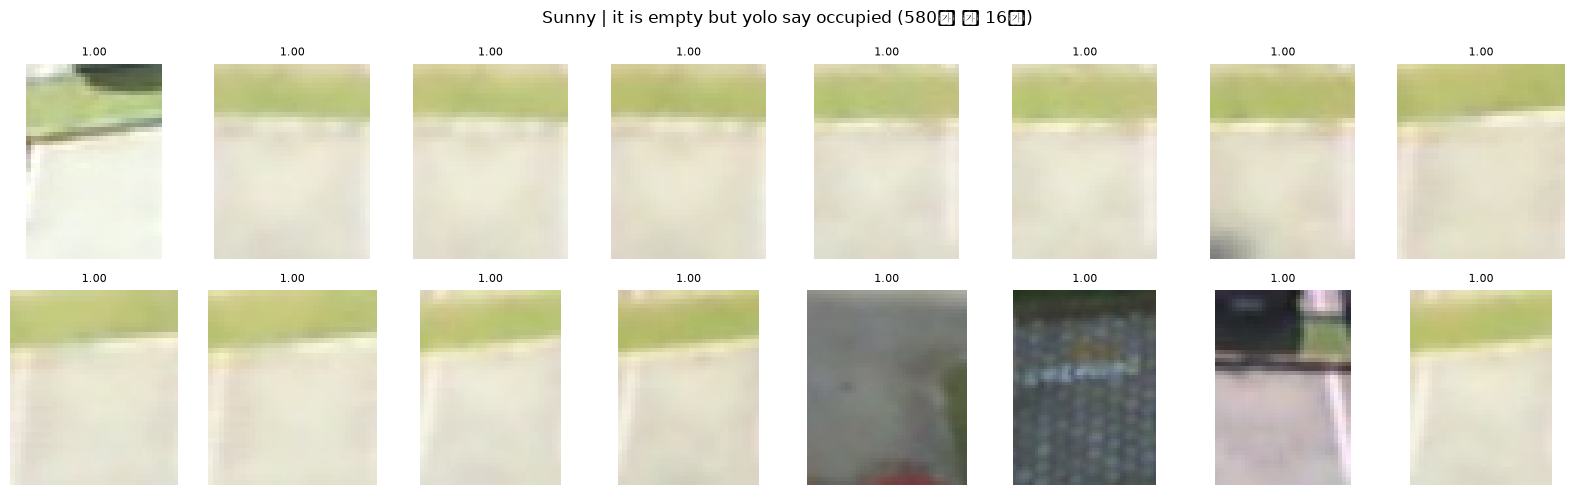

PUC_2012-09-13_13_15_24#087.jpg
PUC_2012-09-13_16_20_32#040.jpg
PUC_2012-10-29_12_03_09#044.jpg
PUC_2012-09-19_12_28_33#039.jpg
PUC_2012-09-18_13_25_07#013.jpg
PUC_2012-09-19_11_53_32#067.jpg
PUC_2012-09-19_15_43_42#018.jpg
PUC_2012-09-20_07_24_17#100.jpg
PUC_2012-10-27_07_40_38#096.jpg
PUC_2012-09-12_16_49_08#031.jpg
PUC_2012-09-12_12_01_14#005.jpg
PUC_2012-09-18_07_34_51#084.jpg
PUC_2012-09-20_07_29_17#100.jpg
PUC_2012-09-19_10_58_30#067.jpg
PUC_2012-09-19_11_28_31#067.jpg
PUC_2012-11-11_16_24_13#068.jpg


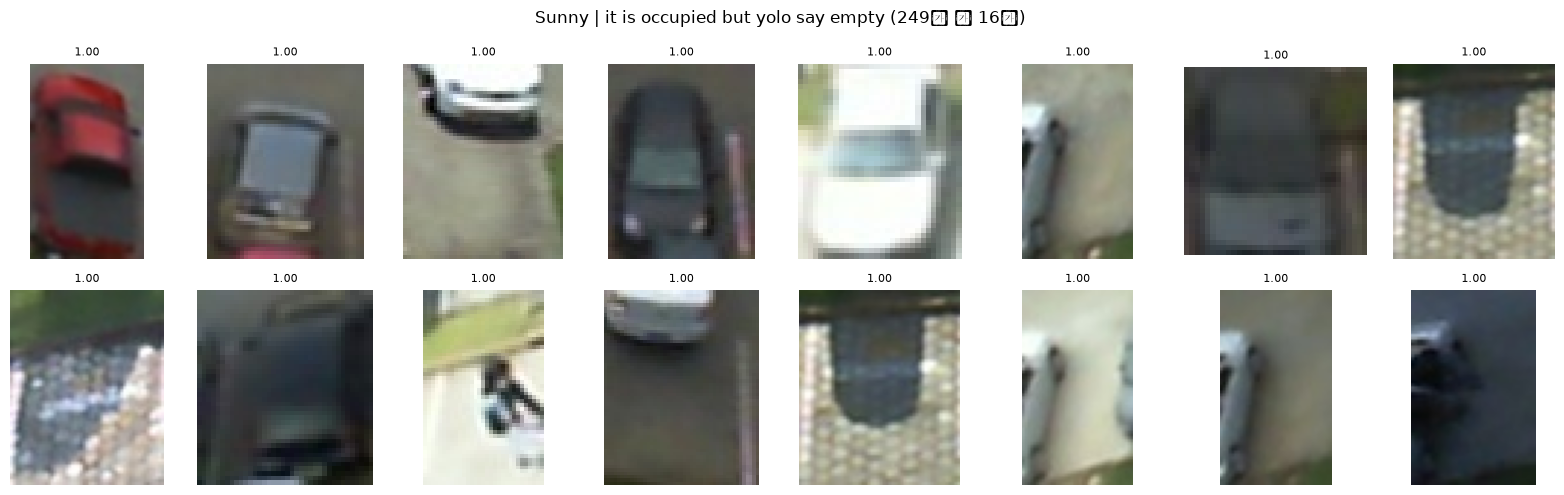

In [21]:
wrong = test_df[(~test_df.correct) & (test_df.weather == "Sunny")]

for kind, sub in [("it is empty but yolo say occupied", wrong[wrong.label == "occupied"]),
                  ("it is occupied but yolo say empty", wrong[wrong.label == "empty"])]:
    sub = sub.sort_values("conf", ascending=False).head(16)   # 확신하고 틀린 것부터
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    fig.suptitle(f"Sunny | {kind} ({len(wrong[wrong.label == sub.label.iloc[0]])}장 중 16장)")
    for ax, r in zip(axes.flat, sub.itertuples()):
        print(Path(r.file).name)
        ax.imshow(cv2.cvtColor(cv2.imread(r.file), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{r.conf:.2f}", fontsize=8)
        ax.axis("off")
    for ax in axes.flat[len(sub):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

[0] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-13\Occupied\2012-09-13_11_10_19#007.jpg
[1] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_31_27#016.jpg
[2] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_36_27#016.jpg
[3] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_41_27#016.jpg
[4] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_31_27#015.jpg
[5] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_36_27#015.jpg
[6] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_41_27#015.jpg
[7] 같은 파일: True | archive\PKLot\PKLotSegmented\PUC\Sunny\2012-09-14\Occupied\2012-09-14_15_41_27#011.jpg


C:\Users\HP\AppData\Local\Temp\ipykernel_11072\402114804.py:20: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_11072\402114804.py:20: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_11072\402114804.py:20: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\AppData\Local\Temp\ipykernel_11072\402114804.py:20: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\I

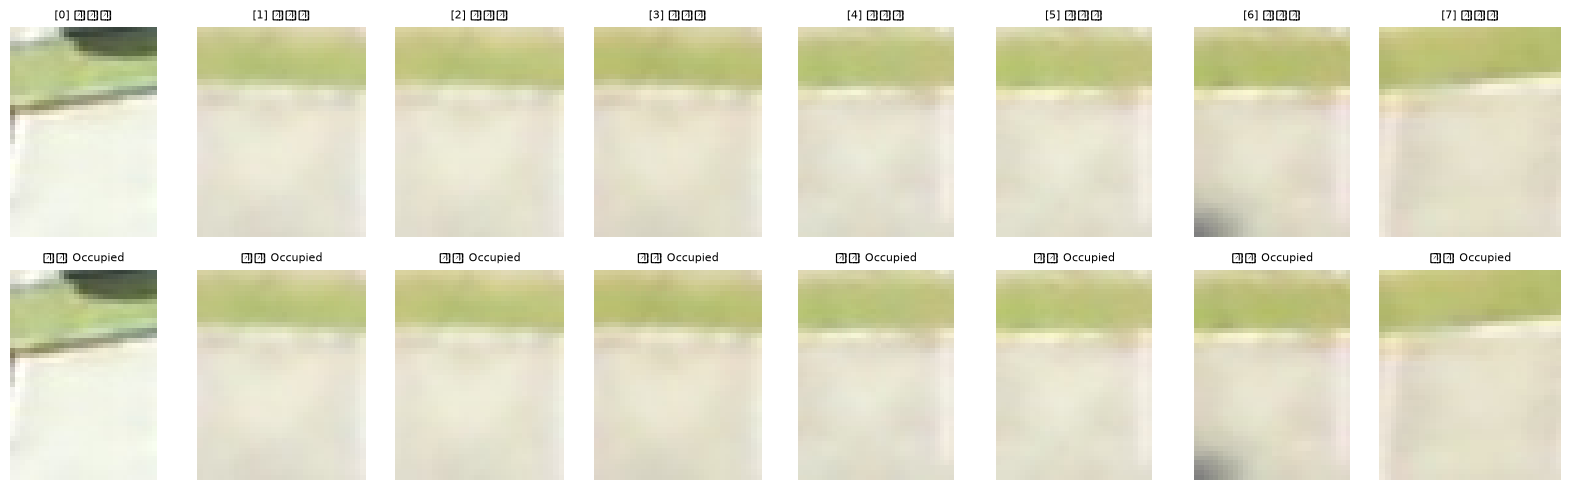

In [22]:
import hashlib

def md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

top = wrong[wrong.label == "occupied"].sort_values("conf", ascending=False).head(8)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, (ax_copy, ax_orig, r) in enumerate(zip(axes[0], axes[1], top.itertuples())):
    name = Path(r.file).name.removeprefix("PUC_")
    seg = SEG_ROOT / "PUC" / r.weather / name[:10] / "Occupied" / name

    ax_copy.imshow(cv2.cvtColor(cv2.imread(r.file), cv2.COLOR_BGR2RGB))
    ax_copy.set_title(f"[{i}] 복사본", fontsize=8); ax_copy.axis("off")
    ax_orig.imshow(cv2.cvtColor(cv2.imread(str(seg)), cv2.COLOR_BGR2RGB))
    ax_orig.set_title("원본 Occupied", fontsize=8); ax_orig.axis("off")

    print(f"[{i}] 같은 파일: {md5(r.file) == md5(seg)} | {seg}")
plt.tight_layout(); plt.show()

In [23]:
print("SEG_ROOT 존재:", SEG_ROOT.exists(), "|", SEG_ROOT.resolve())

r = top.iloc[0]
name = Path(r.file).name.removeprefix("PUC_")
print("찾는 파일:", name)

found = list((SEG_ROOT / "PUC").rglob(name))   # PUC 아래 전체에서 이 이름만 검색
print("찾은 위치:", found)

SEG_ROOT 존재: True | D:\SmartParkingSystem\archive\PKLot\PKLotSegmented
찾는 파일: 2012-09-13_11_10_19#007.jpg
찾은 위치: [WindowsPath('archive/PKLot/PKLotSegmented/PUC/Sunny/2012-09-13/Occupied/2012-09-13_11_10_19#007.jpg')]


0.5~0.7 구간 오류: 179 장


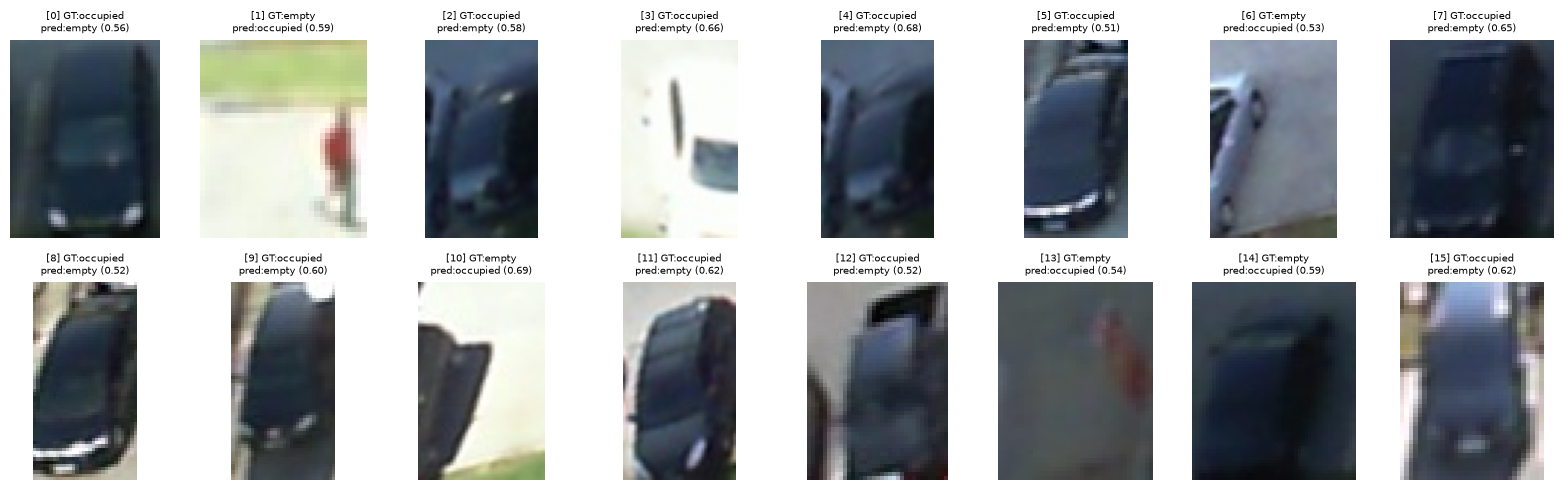

In [24]:
low = wrong[(wrong.conf >= 0.5) & (wrong.conf < 0.7)]
print("0.5~0.7 구간 오류:", len(low), "장")

sub = low.sample(min(16, len(low)), random_state=0)    # 무작위 16장
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, (ax, r) in enumerate(zip(axes.flat, sub.itertuples())):
    ax.imshow(cv2.cvtColor(cv2.imread(r.file), cv2.COLOR_BGR2RGB))
    ax.set_title(f"[{i}] GT:{r.label}\npred:{r.pred} ({r.conf:.2f})", fontsize=7)
    ax.axis("off")
for ax in axes.flat[len(sub):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

In [25]:
check = wrong.sort_values("conf", ascending=False)
for lab in ["empty", "occupied"]:
    print(f"--- 라벨 {lab} ---")
    for r in check[check.label == lab].head(8).itertuples():
        res = best.predict(cv2.imread(r.file), imgsz=96, device=DEVICE, verbose=False)[0]
        now = best.names[res.probs.top1]
        print(f"{Path(r.file).name:35s} 표의 pred={r.pred:9s} | 지금 다시 예측={now:9s} ({float(res.probs.top1conf):.2f})")

--- 라벨 empty ---
PUC_2012-09-13_13_15_24#087.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-13_16_20_32#040.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-10-29_12_03_09#044.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-19_12_28_33#039.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-18_13_25_07#013.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-19_11_53_32#067.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-19_15_43_42#018.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
PUC_2012-09-20_07_24_17#100.jpg     표의 pred=occupied  | 지금 다시 예측=occupied  (1.00)
--- 라벨 occupied ---
PUC_2012-09-13_11_10_19#007.jpg     표의 pred=empty     | 지금 다시 예측=empty     (1.00)
PUC_2012-09-14_15_31_27#016.jpg     표의 pred=empty     | 지금 다시 예측=empty     (1.00)
PUC_2012-09-14_15_36_27#016.jpg     표의 pred=empty     | 지금 다시 예측=empty     (1.00)
PUC_2012-09-14_15_41_27#016.jpg     표의 pred=empty     | 지금 다시

In [26]:
def predict_square(path):
    img = cv2.resize(cv2.imread(path), (96, 96))      # 비율 무시하고 정사각형으로
    res = best.predict(img, imgsz=96, device=DEVICE, verbose=False)[0]
    return best.names[res.probs.top1], float(res.probs.top1conf)

for lab in ["empty", "occupied"]:
    print(f"--- 라벨 {lab} ---")
    for r in check[check.label == lab].head(8).itertuples():
        p, c = predict_square(r.file)
        print(f"{Path(r.file).name:35s} 원래={r.pred:9s} | 정사각형={p:9s} ({c:.2f})")

--- 라벨 empty ---
PUC_2012-09-13_13_15_24#087.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-09-13_16_20_32#040.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-10-29_12_03_09#044.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-09-19_12_28_33#039.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-09-18_13_25_07#013.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-09-19_11_53_32#067.jpg     원래=occupied  | 정사각형=occupied  (0.96)
PUC_2012-09-19_15_43_42#018.jpg     원래=occupied  | 정사각형=occupied  (1.00)
PUC_2012-09-20_07_24_17#100.jpg     원래=occupied  | 정사각형=occupied  (1.00)
--- 라벨 occupied ---
PUC_2012-09-13_11_10_19#007.jpg     원래=empty     | 정사각형=empty     (1.00)
PUC_2012-09-14_15_31_27#016.jpg     원래=empty     | 정사각형=empty     (1.00)
PUC_2012-09-14_15_36_27#016.jpg     원래=empty     | 정사각형=empty     (1.00)
PUC_2012-09-14_15_41_27#016.jpg     원래=empty     | 정사각형=empty     (1.00)
PUC_2012-09-14_15_31_27#015.jpg     원래=empty     | 정사각형=empty     (1.00)
PUC_2012-09-14